## Student Name: Aarti P. Kalyane
## Roll No.: EN231070055
## Batch: B
## Subject: AI&NN

In [ ]:
Colloring the Grid

In [ ]:
def is_valid(region, color, assignment):
    for neighbor in neighbors[region]:
        if assignment.get(neighbor) == color:
            return False
    return True

def select_unassigned_variable(assignment, domains):
    unassigned = [v for v in domains if v not in assignment]
    return min(unassigned, key=lambda var: len(domains[var]))

def order_domain_values(var, assignment, domains):
    def count_conflicts(value):
        count = 0
        for neighbor in neighbors[var]:
            if value in domains[neighbor]:
                count += 1
        return count
    return sorted(domains[var], key=count_conflicts)

def backtrack(assignment, domains):
    if len(assignment) == len(domains):
        return assignment

    var = select_unassigned_variable(assignment, domains)
    for value in order_domain_values(var, assignment, domains):
        if is_valid(var, value, assignment):
            assignment[var] = value
            result = backtrack(assignment, domains)
            if result:
                return result
            del assignment[var]
    return None

def solve_map_coloring():
    domains = {region: colors[:] for region in neighbors}
    assignment = {}
    return backtrack(assignment, domains)


solution = solve_map_coloring()
print("Map Coloring Solution:")
if solution:
    for region in sorted(solution):
        print(f"{region} → {solution[region]}")
else:
    print("No solution found.")

neighbors = {
    'A': ['B', 'C'],
    'B': ['A', 'C', 'D'],
    'C': ['A', 'B', 'D'],
    'D': ['B', 'C']
}
colors = ['Red', 'Green', 'Blue']

Map Coloring Solution:
A → Red
B → Green
C → Blue
D → Red




*   Coloring the graph grid with input from user



In [ ]:
def input_graph():
    n = int(input("Enter number of regions: "))
    neighbors = {}
    print("Enter each region name followed by its neighbors (space-separated):")
    for _ in range(n):
        entry = input().split()
        region = entry[0]
        neighbors_list = entry[1:]
        neighbors[region] = neighbors_list
    return neighbors

def input_colors():
    colors = input("Enter available colors (space-separated): ").split()
    return colors
def is_valid(region, color, assignment, neighbors):
    for neighbor in neighbors[region]:
        if assignment.get(neighbor) == color:
            return False
    return True

def select_unassigned_variable(assignment, domains):
    unassigned = [v for v in domains if v not in assignment]
    return min(unassigned, key=lambda var: len(domains[var]))

def order_domain_values(var, assignment, domains, neighbors):
    def count_conflicts(value):
        count = 0
        for neighbor in neighbors[var]:
            if value in domains[neighbor]:
                count += 1
        return count
    return sorted(domains[var], key=count_conflicts)

def backtrack(assignment, domains, neighbors):
    if len(assignment) == len(domains):
        return assignment

    var = select_unassigned_variable(assignment, domains)
    for value in order_domain_values(var, assignment, domains, neighbors):
        if is_valid(var, value, assignment, neighbors):
            assignment[var] = value
            result = backtrack(assignment, domains, neighbors)
            if result:
                return result
            del assignment[var]
    return None

def solve_map_coloring():
    neighbors = input_graph()
    colors = input_colors()
    domains = {region: colors[:] for region in neighbors}
    assignment = {}
    solution = backtrack(assignment, domains, neighbors)

    print("\nMap Coloring Solution:")
    if solution:
        for region in sorted(solution):
            print(f"{region} → {solution[region]}")
    else:
        print("No solution found.")

if __name__ == "__main__":
    solve_map_coloring()

Enter number of regions: 5
Enter each region name followed by its neighbors (space-separated):
A C D F B
B A F
C A D 
D C A
F A B
Enter available colors (space-separated): RED GREEN BLUE

Map Coloring Solution:
A → RED
B → GREEN
C → GREEN
D → BLUE
F → BLUE


Enter number of regions: 4
Enter each region name followed by its neighbors (space-separated):
A B C
B A C D
C A B D
D B C
Enter available colors (space-separated): RED BLUE GREEN

Map Coloring Solution:
A → RED
B → BLUE
C → GREEN
D → RED


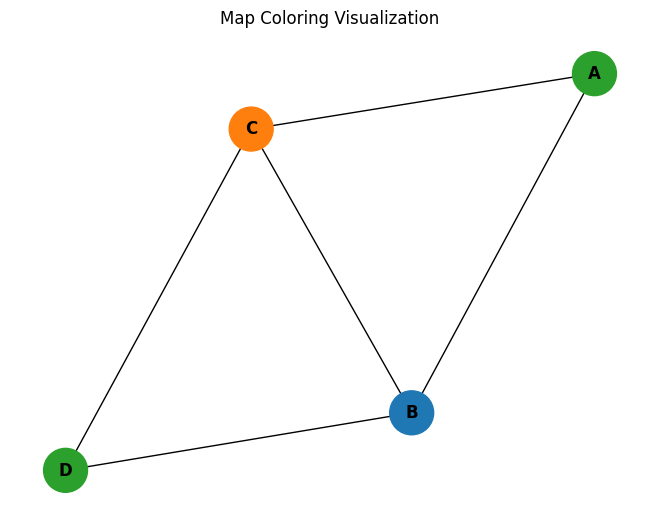

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

def input_graph():
    n = int(input("Enter number of regions: "))
    neighbors = {}
    print("Enter each region name followed by its neighbors (space-separated):")
    for _ in range(n):
        entry = input().split()
        region = entry[0]
        neighbors_list = entry[1:]
        neighbors[region] = neighbors_list
    return neighbors


def input_colors():
    return input("Enter available colors (space-separated): ").split()


def is_valid(region, color, assignment, neighbors):
    for neighbor in neighbors[region]:
        if assignment.get(neighbor) == color:
            return False
    return True


def backtrack(assignment, colors, neighbors):
    if len(assignment) == len(neighbors):
        return assignment

    for region in neighbors:
        if region not in assignment:
            for color in colors:
                if is_valid(region, color, assignment, neighbors):
                    assignment[region] = color
                    result = backtrack(assignment, colors, neighbors)
                    if result:
                        return result
                    del assignment[region]
            return None
    return None

def draw_graph(neighbors, solution):
    G = nx.Graph()

    for region, adjacent in neighbors.items():
        for neighbor in adjacent:
            G.add_edge(region, neighbor)

    color_map = []
    unique_colors = list(set(solution.values()))
    color_palette = {
        color: plt.cm.tab10(i % 10)
        for i, color in enumerate(unique_colors)
    }
    for node in G.nodes():
        color_map.append(color_palette[solution.get(node, 'gray')])

    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, with_labels=True, node_color=color_map, edge_color='black', node_size=1000, font_weight='bold')
    plt.title("Map Coloring Visualization")
    plt.show()

def solve_map_coloring():
    neighbors = input_graph()
    colors = input_colors()
    assignment = {}
    solution = backtrack(assignment, colors, neighbors)

    print("\nMap Coloring Solution:")
    if solution:
        for region in sorted(solution):
            print(f"{region} → {solution[region]}")
        draw_graph(neighbors, solution)
    else:
        print("No solution found.")

if __name__ == "__main__":
    solve_map_coloring()

In [ ]:
Sudoku

In [ ]:
def is_valid(board, row, col, num):
    for i in range(9):
        if board[row][i] == num or board[i][col] == num:
            return False
    start_row, start_col = 3 * (row // 3), 3 * (col // 3)
    for r in range(start_row, start_row + 3):
        for c in range(start_col, start_col + 3):
            if board[r][c] == num:
                return False
    return True

def find_empty_cell_mrv(board):
    min_options = 10
    best_cell = None
    for r in range(9):
        for c in range(9):
            if board[r][c] == 0:
                options = [num for num in range(1, 10) if is_valid(board, r, c, num)]
                if len(options) < min_options:
                    min_options = len(options)
                    best_cell = (r, c)
    return best_cell

def sudoku_solver(board):
    cell = find_empty_cell_mrv(board)
    if not cell:
        return True
    row, col = cell
    for num in range(1, 10):
        if is_valid(board, row, col, num):
            board[row][col] = num
            if sudoku_solver(board):
                return True
            board[row][col] = 0
    return False

def print_sudoku(board):
    for i, row in enumerate(board):
        print(" ".join(str(num) if num != 0 else '.' for num in row))
        if i % 3 == 2 and i != 8:
            print("-" * 21)


sudoku_board = [
    [5, 3, 0, 0, 7, 0, 0, 0, 0],
    [6, 0, 0, 1, 9, 5, 0, 0, 0],
    [0, 9, 8, 0, 0, 0, 0, 6, 0],

    [8, 0, 0, 0, 6, 0, 0, 0, 3],
    [4, 0, 0, 8, 0, 3, 0, 0, 1],
    [7, 0, 0, 0, 2, 0, 0, 0, 6],

    [0, 6, 0, 0, 0, 0, 2, 8, 0],
    [0, 0, 0, 4, 1, 9, 0, 0, 5],
    [0, 0, 0, 0, 8, 0, 0, 7, 9]
]

print("Sudoku Puzzle:")
print_sudoku(sudoku_board)
if sudoku_solver(sudoku_board):
    print("\nSolved Sudoku:")
    print_sudoku(sudoku_board)
else:
    print("No solution exists.")

Sudoku Puzzle:
5 3 . . 7 . . . .
6 . . 1 9 5 . . .
. 9 8 . . . . 6 .
---------------------
8 . . . 6 . . . 3
4 . . 8 . 3 . . 1
7 . . . 2 . . . 6
---------------------
. 6 . . . . 2 8 .
. . . 4 1 9 . . 5
. . . . 8 . . 7 9

Solved Sudoku:
5 3 4 6 7 8 9 1 2
6 7 2 1 9 5 3 4 8
1 9 8 3 4 2 5 6 7
---------------------
8 5 9 7 6 1 4 2 3
4 2 6 8 5 3 7 9 1
7 1 3 9 2 4 8 5 6
---------------------
9 6 1 5 3 7 2 8 4
2 8 7 4 1 9 6 3 5
3 4 5 2 8 6 1 7 9


**Sudoku with input from user**

In [ ]:
def is_valid(board, row, col, num):
    for i in range(9):
        if board[row][i] == num or board[i][col] == num:
            return False
    start_row, start_col = 3 * (row // 3), 3 * (col // 3)
    for r in range(start_row, start_row + 3):
        for c in range(start_col, start_col + 3):
            if board[r][c] == num:
                return False
    return True

def find_empty_cell(board):
    for r in range(9):
        for c in range(9):
            if board[r][c] == 0:
                return (r, c)
    return None

def sudoku_solver(board):
    empty = find_empty_cell(board)
    if not empty:
        return True
    row, col = empty
    for num in range(1, 10):
        if is_valid(board, row, col, num):
            board[row][col] = num
            if sudoku_solver(board):
                return True
            board[row][col] = 0
    return False

def print_sudoku(board):
    for i, row in enumerate(board):
        print(" ".join(str(num) if num != 0 else '.' for num in row))
        if i % 3 == 2 and i != 8:
            print("-" * 21)

def input_sudoku():
    print("Enter your Sudoku puzzle (row-wise, 9 numbers per row separated by space; use 0 for empty cells):")
    board = []
    for i in range(9):
        while True:
            try:
                row = list(map(int, input(f"Row {i+1}: ").strip().split()))
                if len(row) == 9 and all(0 <= num <= 9 for num in row):
                    board.append(row)
                    break
                else:
                    print("Invalid input. Please enter exactly 9 numbers between 0 and 9.")
            except ValueError:
                print("Invalid input. Please enter integers only.")
    return board


sudoku_board = input_sudoku()

print("\nSudoku Puzzle:")
print_sudoku(sudoku_board)

if sudoku_solver(sudoku_board):
    print("\nSolved Sudoku:")
    print_sudoku(sudoku_board)
else:
    print("No solution exists.")

Enter your Sudoku puzzle (row-wise, 9 numbers per row separated by space; use 0 for empty cells):
Row 1: 5 3 0 0 7 0 0 0 0
Row 2: 6 0 0 1 9 5 0 0 0
Row 3: 0 9 8 0 0 0 0 6 0
Row 4: 8 0 0 0 6 0 0 0 3
Row 5: 4 0 0 8 0 3 0 0 1
Row 6: 7 0 0 0 2 0 0 0 6
Row 7: 0 6 0 0 0 0 2 8 0
Row 8: 0 0 0 4 1 9 0 0 5
Row 9: 0 0 0 0 8 0 0 7 9

Sudoku Puzzle:
5 3 . . 7 . . . .
6 . . 1 9 5 . . .
. 9 8 . . . . 6 .
---------------------
8 . . . 6 . . . 3
4 . . 8 . 3 . . 1
7 . . . 2 . . . 6
---------------------
. 6 . . . . 2 8 .
. . . 4 1 9 . . 5
. . . . 8 . . 7 9

Solved Sudoku:
5 3 4 6 7 8 9 1 2
6 7 2 1 9 5 3 4 8
1 9 8 3 4 2 5 6 7
---------------------
8 5 9 7 6 1 4 2 3
4 2 6 8 5 3 7 9 1
7 1 3 9 2 4 8 5 6
---------------------
9 6 1 5 3 7 2 8 4
2 8 7 4 1 9 6 3 5
3 4 5 2 8 6 1 7 9
